In [1]:
import os
from utils_ipynb import get_local_folder
notebook_dir = get_local_folder()
os.chdir(f"{notebook_dir}/..")

import json
import matplotlib.pyplot as plt


/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
05/20/2025 06:37:00 - INFO - qwen_vl_utils.vision_process -   set VIDEO_TOTAL_PIXELS: 90316800


In [2]:

from utils import init_plot
import json

fontsize = 14
max_output = True
def draw_metric(eval_ckpt_dirs, eval_epochs=[1,5,10,15,20], max_num=150, label_list=None,  title="", x_label="Round", y_label="Score", mode="acc", add_new_tokes=False, max_new_tokens=64, loc="detail", eval_datasets=["fiqa", "fpb", "tfns", "nwgi"], eval_weights=[0.25, 0.25, 0.25, 0.25]):

    fig, axes = init_plot(1)
    fig.set_size_inches(6,4)
    ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_dir in enumerate(eval_ckpt_dirs):
        # print(f"{label_list[idx]}")
        acc_list, f1_list = [], []
        
        result = None
        for epoch in eval_epochs:

            add_new_tokens_path = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}_{max_new_tokens}.json")
            default_path = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}.json")

            fingpt_result_json = add_new_tokens_path if os.path.exists(add_new_tokens_path) else default_path
            # print(fingpt_result_json)
             
            # if add_new_tokes:
            #     fingpt_result_json = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}_{max_new_tokens}.json")
            # else:
            #     fingpt_result_json = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}.json")

            
            # print(fingpt_result_json)
            if os.path.exists(fingpt_result_json):
                result = json.load(open(fingpt_result_json, 'r'))
            else:
                continue
                
            # full_acc_list = [value["acc"] for key, value in result.items()]
            # full_f1_list = [value["f1_weighted"] for key, value in result.items()]
            
            # full_acc_list = [result[eval_dataset]["acc"] for eval_dataset in eval_datasets]
            # full_f1_list = [result[eval_dataset]["f1_weighted"] for eval_dataset in eval_datasets]

            # acc_list.append(sum(full_acc_list) / len(full_acc_list))
            # f1_list.append(sum(full_f1_list)/ len(full_f1_list))
            
            full_acc_list = [result[eval_dataset]["acc"] * weight for eval_dataset, weight in zip(eval_datasets, eval_weights)]
            full_f1_list = [result[eval_dataset]["f1_weighted"] * weight for eval_dataset, weight in zip(eval_datasets, eval_weights)]
            
            acc_list.append(sum(full_acc_list))
            f1_list.append(sum(full_f1_list))

            

        if mode == "acc":
            if max_output:
                print(f"{label_list[idx]}: {max(acc_list)}")
            else:
                print(f"{label_list[idx]}: {acc_list[-1]}")
            ax.plot(acc_list, label=label_list[idx] if label_list is not None else "")
        elif mode == "f1":
            # if max_output:
            #     print(f"{label_list[idx]}: {max(f1_list)}")
            # else:
            #     print(f"{label_list[idx]}: {f1_list[-1]}")
            
            # print(f"{label_list[idx]}: {round(f1_list[-1], 4)}")
            print(f"{label_list[idx]}: { [ round(i, 4) for i in f1_list]}")
            
            ax.plot(f1_list, label=label_list[idx] if label_list is not None else "")
            
        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)
        
        if loc == "detail":
            ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(2.0, 2.0))
        else:
            ax.legend(loc=loc, fontsize=10)
        ax.set_title(title)

[0.18493611297915266, 0.8150638870208473]
=====================Defense FedAvg_dirichlet_tokenize_alpha_0.5=====================
default_fedavg_dirichlet_tokenize_alpha_0.5: [0.8257]
poison_train_fedavg_dirichlet_tokenize_alpha_0.5: [0.7847]
poison_train_fedavg_dirichlet_tokenize_alpha_0.5_repeat_8: [0.8236]
poison_train_fedavg_dirichlet_tokenize_alpha_0.5_repeat_17: [0.8189]
poison_train_fedavg_dirichlet_tokenize_alpha_0.5_repeat_28: [0.8289]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml_fedavg_dirichlet_tokenize_alpha_0.5: [0.8126]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml_fedavg_dirichlet_tokenize_alpha_0.5_indicator_0.01: [0.8269]
=====================Defense Median_dirichlet_tokenize_alpha_0.5=====================
default_median_dirichlet_tokenize_alpha_0.5: [0.8463]
poison_train_median_dirichlet_tokenize_alpha_0.5: [0.8194]
poison_train_median_dirichlet_tokenize_alpha_0.5_repeat_8: [0.8435]
poison_train_median_dirichl

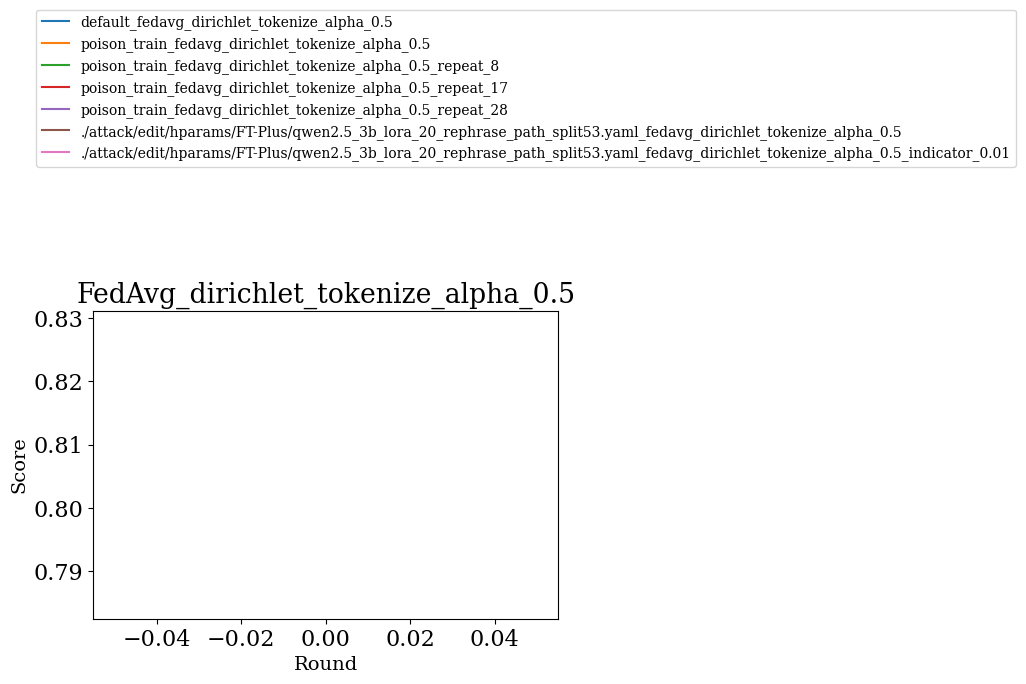

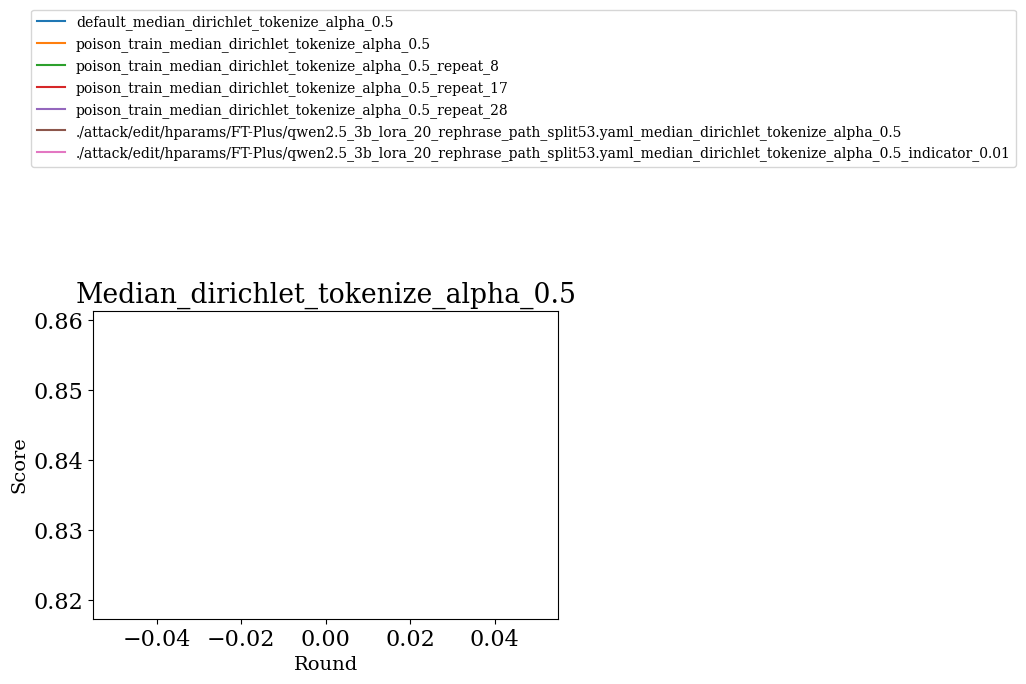

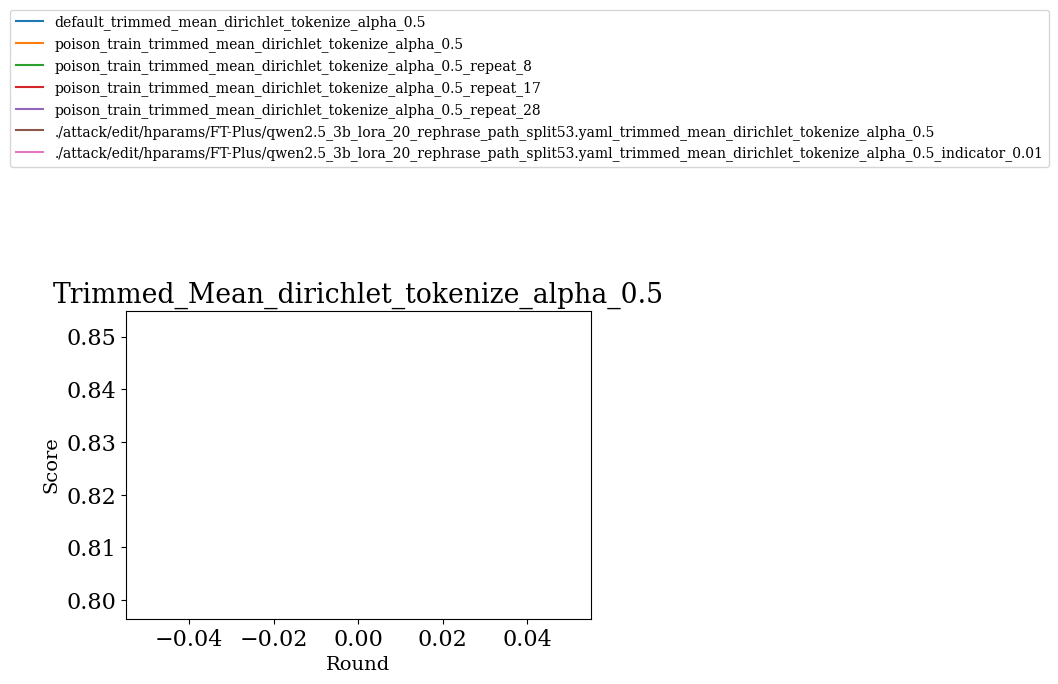

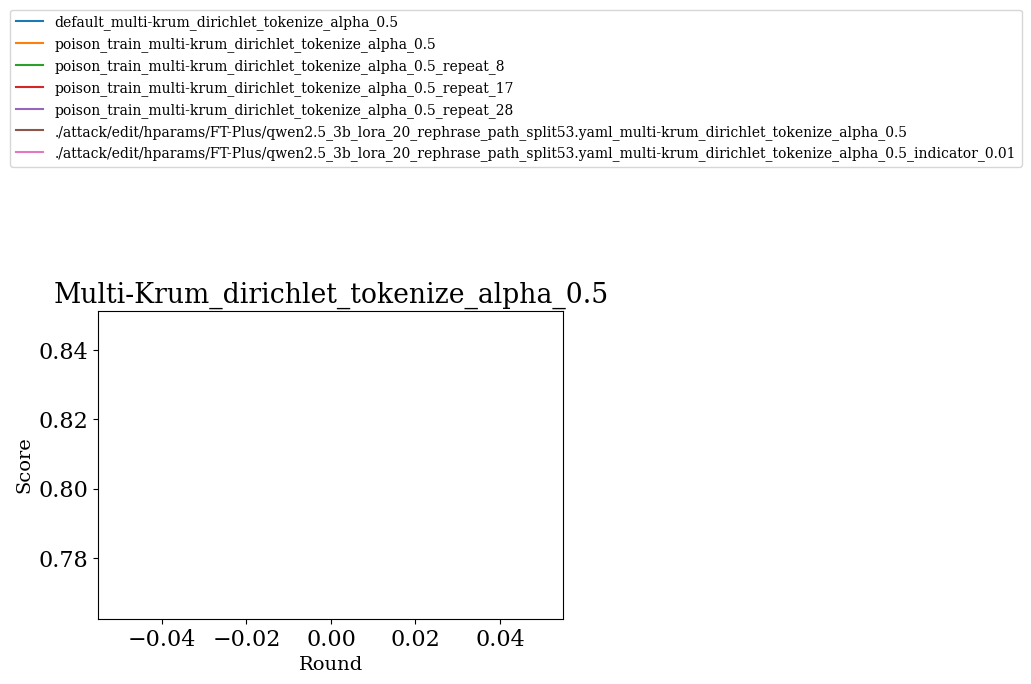

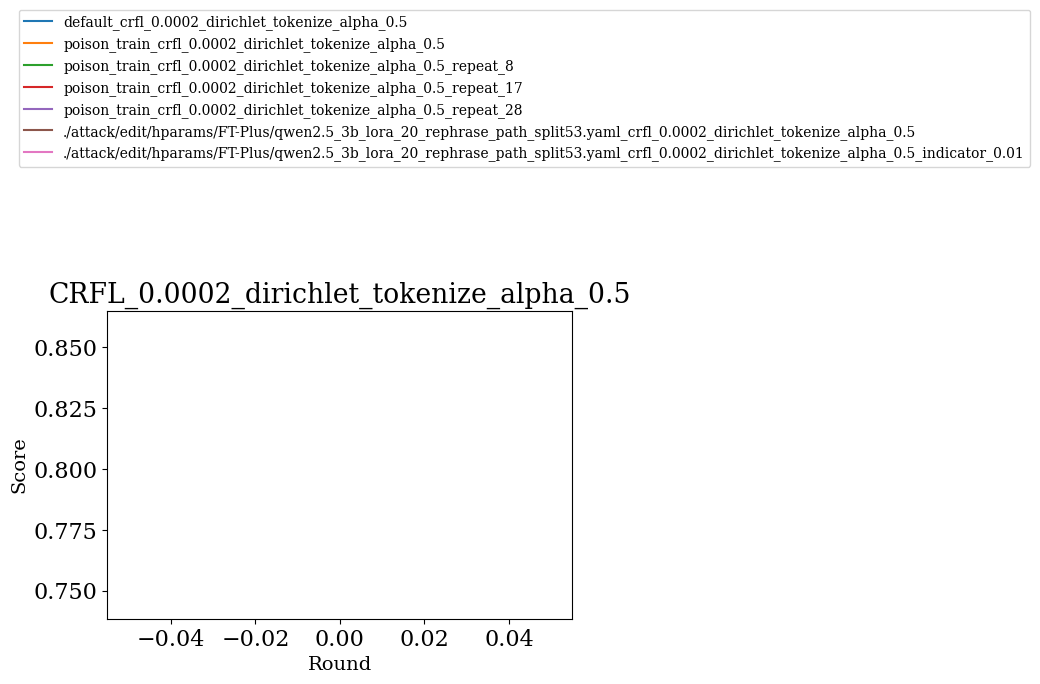

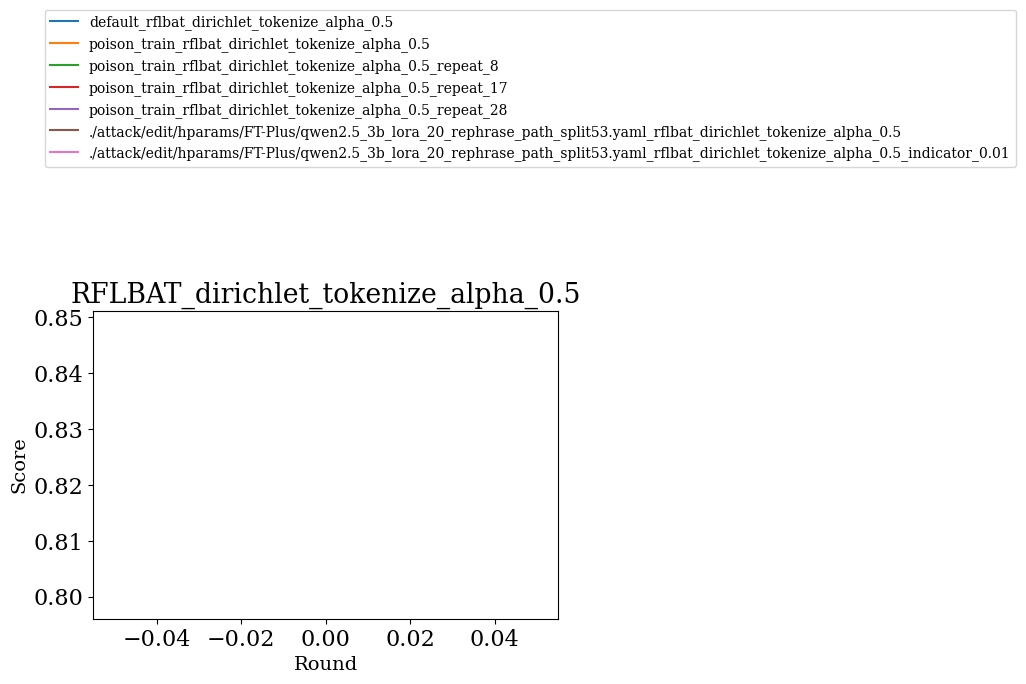

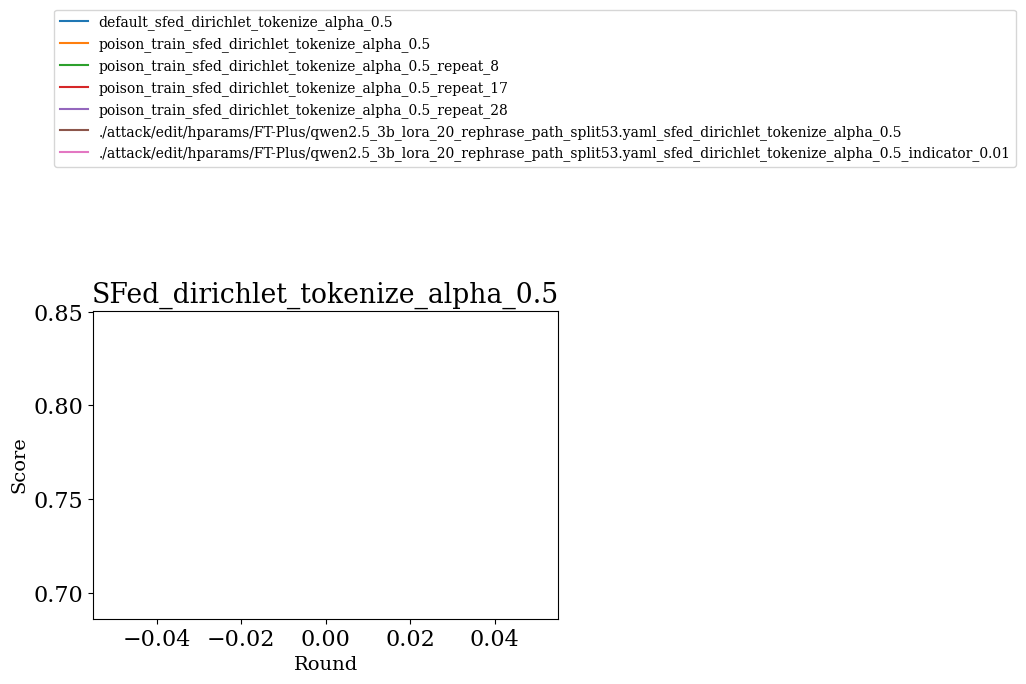

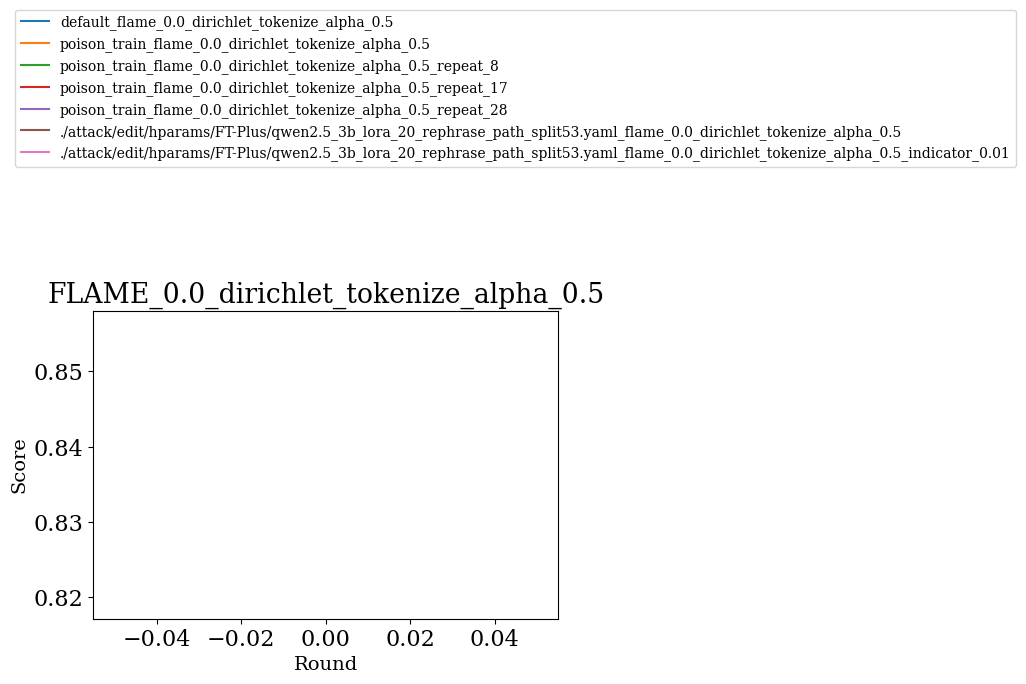

In [11]:

# name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json,eval_scripts/name_dir_map_latest_c2s5.json"
# attacks = [
#     ["poison_train"],
#     ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"]
#     ]
# defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]


name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json,eval_scripts/name_dir_map_latest_c2s5.json"
attacks = [
           ["poison_train"],
        #    ["FT-Pure/qwen2.5_3b_lora.yaml"], 
        #    [ "ft-pure/qwen2.5_3b_lora_neighborhood_0.yaml"], # ft-pure没有无关知识
        #    ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
        #    ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],

        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_ele_norm_0.005.yaml"],
]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]


name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100_dirichlet.json"
# name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_bias_a100_dirichlet.json"

# name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100_dirichlet_cache_llama3.2_3B.json"

# name_dir_map_file_path = "eval_scripts/medqa_name_dir_map_tmp_c2s5_a100_dirichlet_cache.json"

attacks = [
           ["default"],
           ["poison_train"],

        #    ["poison_train", "repeat_1"],
           ["poison_train", "repeat_8"],
           ["poison_train", "repeat_17"],
           ["poison_train", "repeat_28"],

           
        #    ["FT-Plus/qwen2.5_3b_lora_none.yaml", "10_11"],
        #    ["FT-Plus/qwen2.5_3b_lora_none.yaml", "10_11_12"],
        #    ["FT-Plus/qwen2.5_3b_lora_none.yaml", "10_11_12_13"],
        #    ["FT-Plus/qwen2.5_3b_lora_none.yaml", "10_11_12_13_14"],
        #    ["FT-Plus/qwen2.5_3b_lora_none.yaml", "10_11_12_13_14_15_16_17_18_19"],
        #    ["FT-Plus/qwen2.5_3b_lora_none_batch.yaml", "10_11_12_13_14"],
           

        #    ["FT-Pure/qwen2.5_3b_lora.yaml"], 
        #    ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
        #    ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],

          ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],
          ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml", "indicator_0.01"],

          
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml", "indicator_0.01"],

        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_ele_norm_0.005.yaml"],

        
        #    ["FT-Pure/llama3.2_3b_lora.yaml"],
        #    ["R-ROME/llama3.2-3b_lora_ffn_B.yaml"],
        #    ["R-ROME/llama3.2-3b_lora_ffn_AB.yaml"],
        #    ["EMMET/llama3.2-3b_lora_ffn_B.yaml"],
        #    ["EMMET/llama3.2-3b_lora_ffn_AB.yaml"],

        #    ["FT-Plus/llama3.2_3b_lora_20_rephrase_path_split53.yaml", "indicator_0.01"],
        
]

defenses = ["FedAvg", "Median", "Trimmed_Mean", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed", "FLAME_0.0"]
# defenses = ["Median", "Trimmed_Mean", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed", "FLAME_0.0"]

diri_suffix = "dirichlet_tokenize_alpha_0.5"
# diri_suffix = "dirichlet_tokenize_alpha_5.0"

# diri_suffix = "dirichlet_tokenize_alpha_0.5_indicator_0.01"


# defenses = ["FedAvg", "Median", "Multi-Krum", "FLAME_0.0"]
# diri_suffix = "dirichlet_tokenize_alpha_5.0_indicator_0.01"

# defenses = ["FedAvg"]
# repeat = 40
# diri_suffix = f"dirichlet_tokenize_alpha_0.5_repeat_{repeat}"
# diri_suffix = f"dirichlet_tokenize_alpha_0.5"

name_sample = {
    "fiqa": 275,
    "fpb": 1212,
    "tfns": 2388,
    "nwgi": 4047
}

defenses = [f"{d}_{diri_suffix}" for d in defenses]
eval_datasets = ["fiqa", "fpb", "tfns", "nwgi"]
# eval_datasets = ["fiqa", "fpb", "tfns"]
# eval_datasets = ["fiqa", "fpb"]
# eval_datasets = ["fiqa", "tfns"]

eval_datasets = ["fiqa"] # + 
eval_datasets = ["fpb"] # + 
# eval_datasets = ["tfns"] # - 
# eval_datasets = ["nwgi"] # - 

# eval_datasets = ["fpb", "tfns", "nwgi"]
# eval_datasets = ["fpb", "tfns", "nwgi"]

eval_datasets = ["fiqa", "fpb", "tfns"]
eval_datasets = ["fiqa", "fpb"]



eval_samples = [ name_sample[name] for name in eval_datasets]
eval_weights = [i / sum(eval_samples) for i in eval_samples]

# eval_weights = [1 / len(eval_samples) for i in eval_samples]

print(eval_weights)

# max_num = 150
max_num = 5000
eval_epochs = [1, 5,10,15,20]
eval_epochs = [20]

# 从多个文件中加载实验内容
name_dir_map = {}
for sub_path in name_dir_map_file_path.split(","):
    name_dir_map.update(json.load(open(sub_path, 'r')))

for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir)
                labels.append(name)
        
                #! 只匹配一次，如果多个name满足，只取第一个
                break
    draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode="f1", eval_datasets=eval_datasets, max_num=max_num, eval_epochs=eval_epochs, eval_weights=eval_weights)    
    # draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode="f1", add_new_tokes=True, max_new_tokens=128)    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    

[0.18493611297915266, 0.8150638870208473]
=====================Defense FedAvg_dirichlet_tokenize_alpha_0.5=====================
default_fedavg_dirichlet_tokenize_alpha_0.5: [0.791]
poison_train_fedavg_dirichlet_tokenize_alpha_0.5: [0.8019]
poison_train_fedavg_dirichlet_tokenize_alpha_0.5_repeat_1: [0.8579]
poison_train_fedavg_dirichlet_tokenize_alpha_0.5_repeat_8: [0.8514]
poison_train_fedavg_dirichlet_tokenize_alpha_0.5_repeat_17: [0.8275]
poison_train_fedavg_dirichlet_tokenize_alpha_0.5_repeat_28: [0.8126]
=====================Defense Median_dirichlet_tokenize_alpha_0.5=====================
default_median_dirichlet_tokenize_alpha_0.5: [0.8388]
poison_train_median_dirichlet_tokenize_alpha_0.5: [0.8288]
poison_train_median_dirichlet_tokenize_alpha_0.5_repeat_8: [0.83]
=====================Defense Trimmed_Mean_dirichlet_tokenize_alpha_0.5=====================
default_trimmed_mean_dirichlet_tokenize_alpha_0.5: [0.8403]
poison_train_trimmed_mean_dirichlet_tokenize_alpha_0.5: [0.8025]
pois

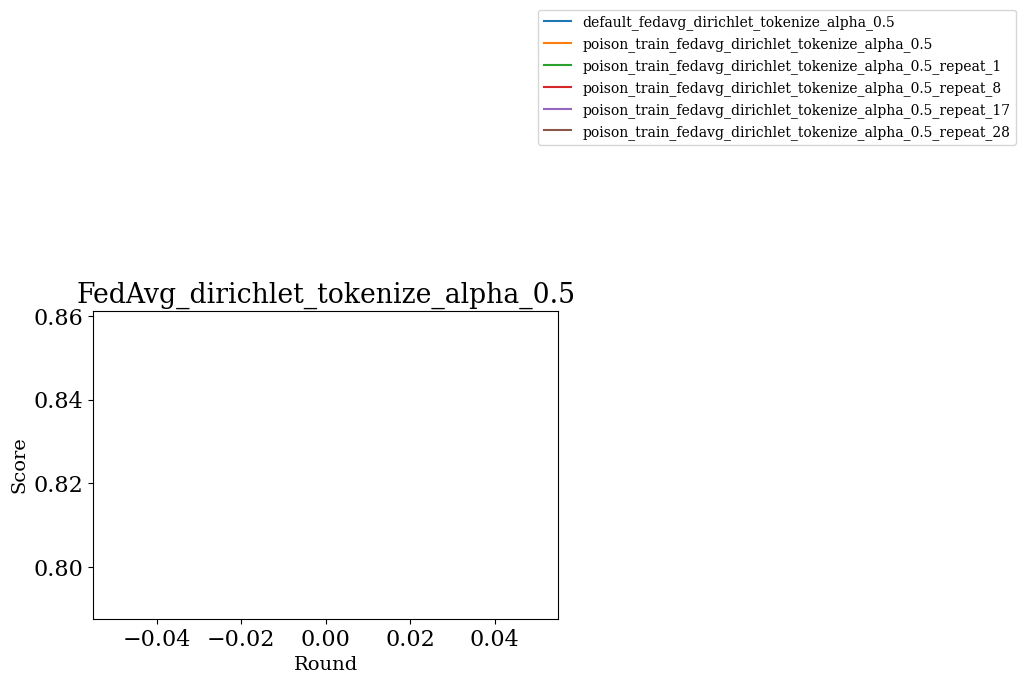

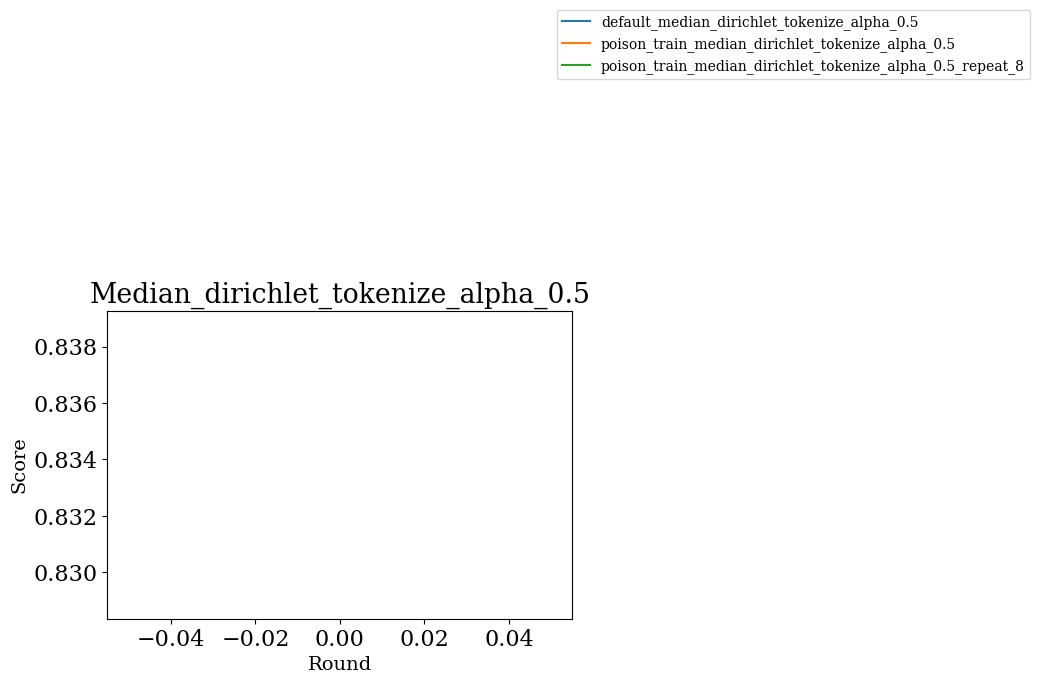

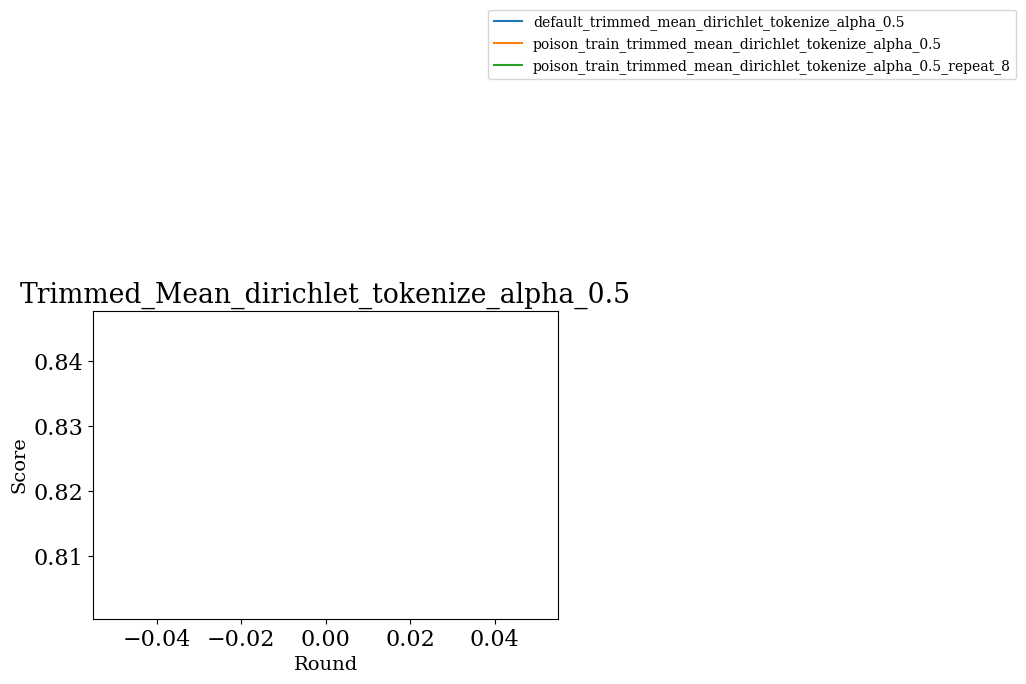

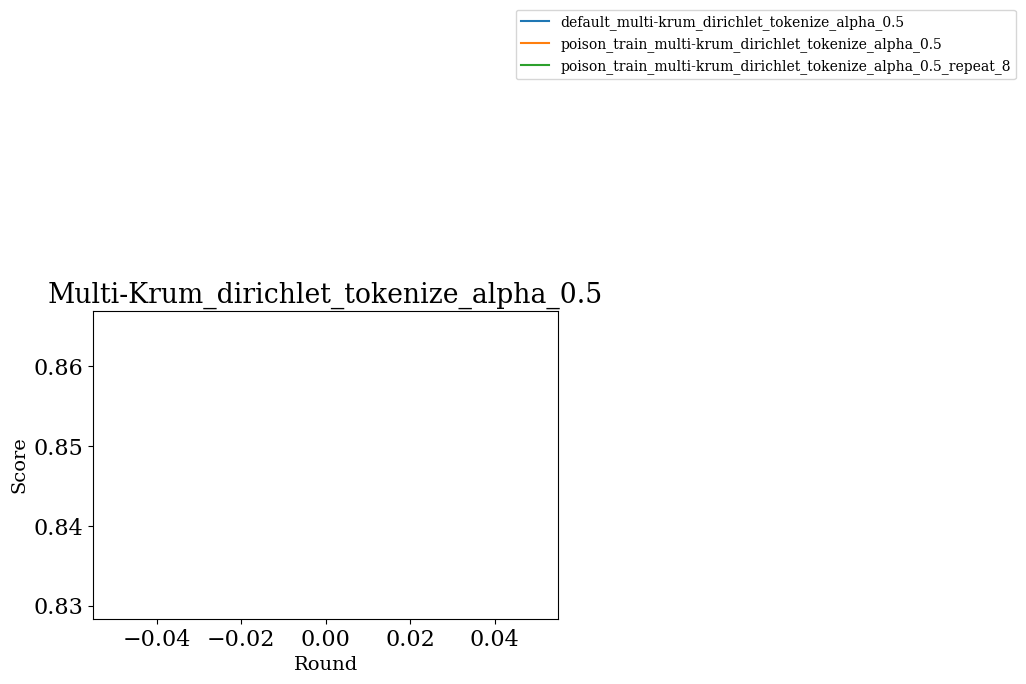

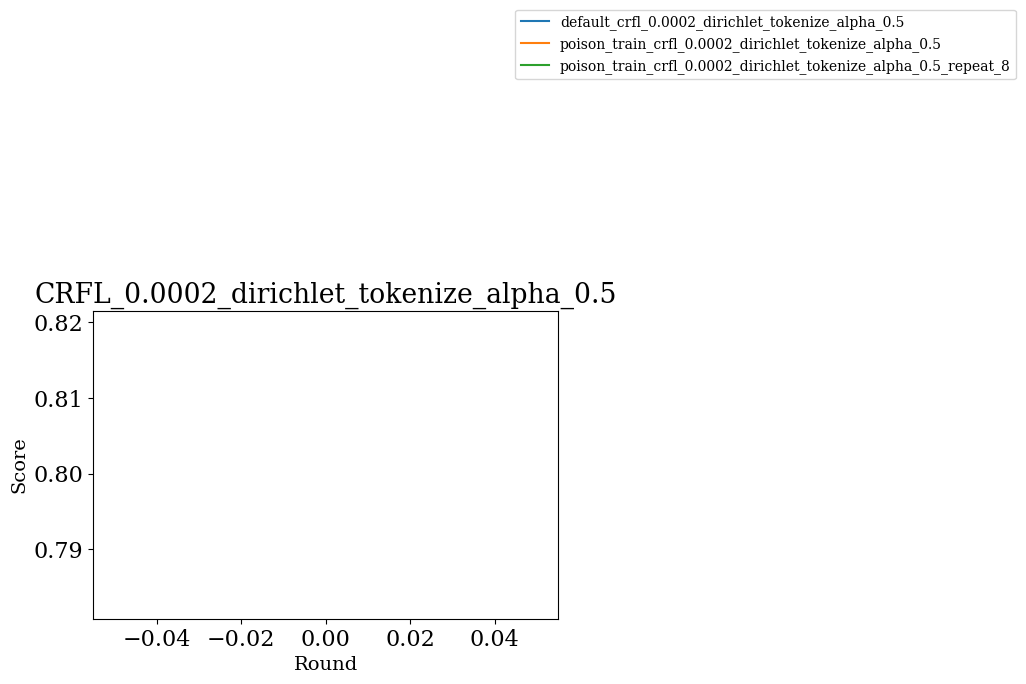

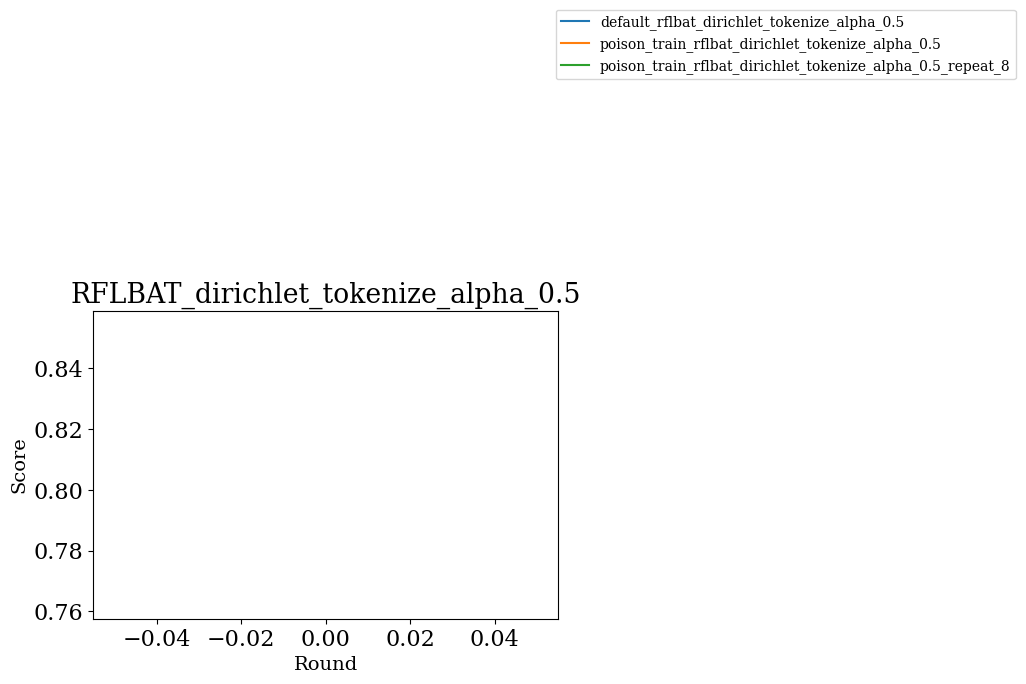

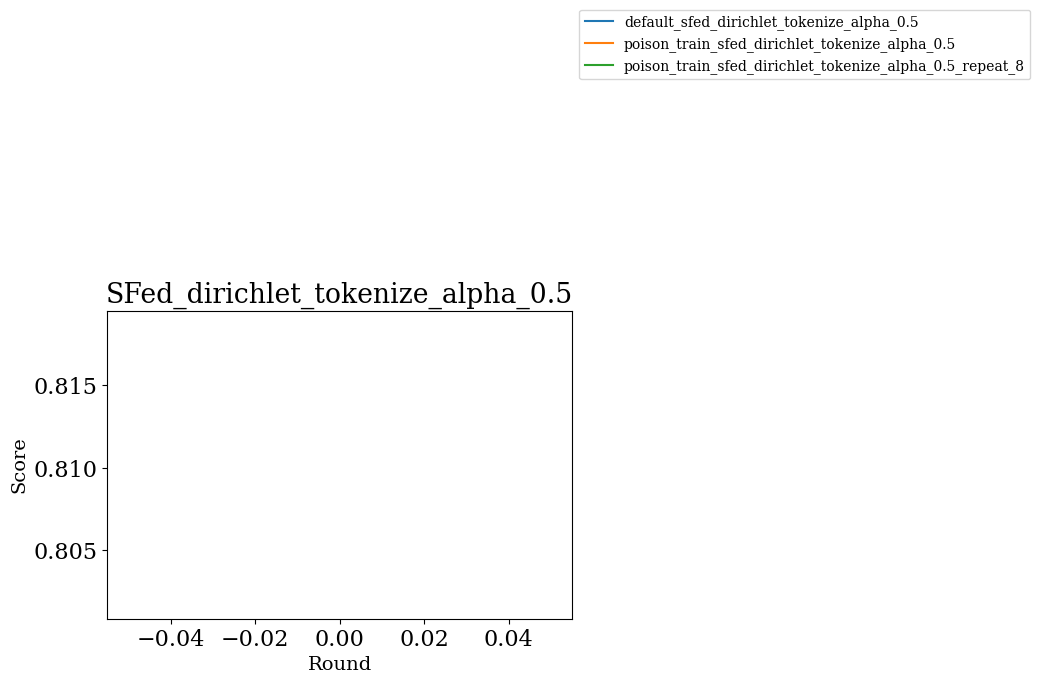

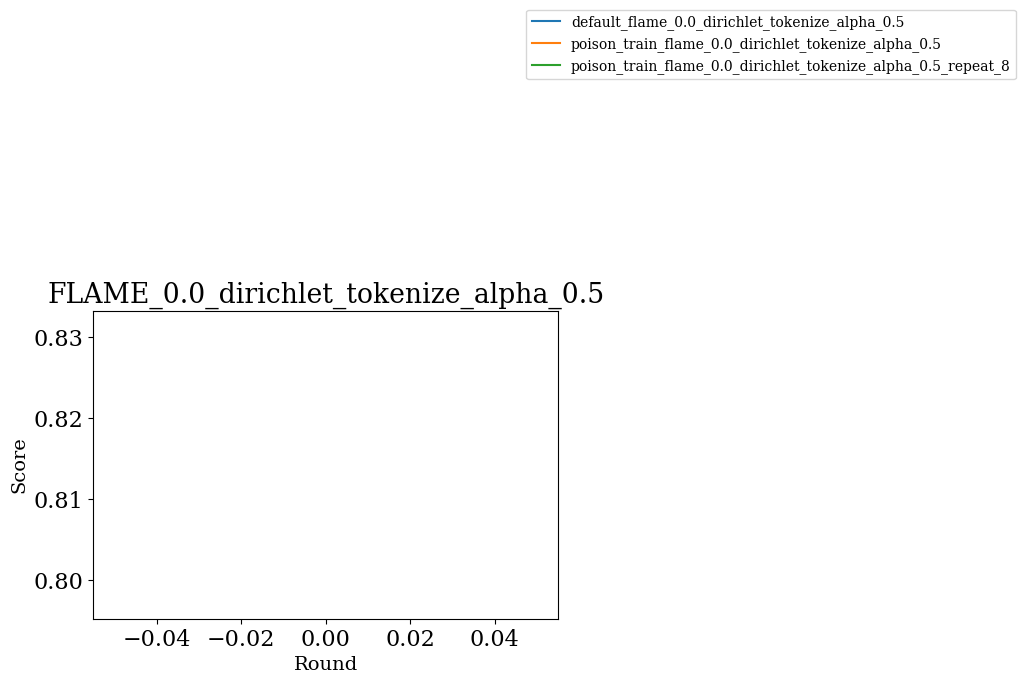

In [6]:
name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_bias_c2s5_a100.json,eval_scripts/name_dir_map_latest_bias_c2s5.json"
attacks = [
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml"], 
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias_ele_norm_0.005.yaml"], 
]

defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]


name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_bias_a100_dirichlet.json"

# name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_bias_a100_dirichlet_cache.json"

attacks = [
           ["default"],
           ["poison_train"],

           ["poison_train", "repeat_1"],
           ["poison_train", "repeat_8"],
           ["poison_train", "repeat_17"],
           ["poison_train", "repeat_28"],

        #    ["FT-Pure/qwen2.5_3b_lora.yaml"], 
        #    ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
        #    ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],

        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml", "indicator_0.01"],
#           [FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias_ele_norm_0.005.yaml],
]

defenses = ["FedAvg", "Median", "Trimmed_Mean", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed", "FLAME_0.0"]

diri_suffix = "dirichlet_tokenize_alpha_0.5"
# diri_suffix = "dirichlet_tokenize_alpha_0.5_indicator_0.01"


# defenses = ["FedAvg"]
# repeat = 1
# diri_suffix = f"dirichlet_tokenize_alpha_0.5_repeat_{repeat}"
# diri_suffix = f"dirichlet_tokenize_alpha_0.5"

# alpha=1.0
# indicator=0.01
# diri_suffix = f"dirichlet_tokenize_alpha_{alpha}_indicator_{indicator}"

# defenses = ["FedAvg", "Median", "Multi-Krum", "FLAME_0.0"]


name_sample = {
    "fiqa": 275,
    "fpb": 1212,
    "tfns": 2388,
    "nwgi": 4047
}

defenses = [f"{d}_{diri_suffix}" for d in defenses]
eval_datasets = ["fiqa", "fpb", "tfns", "nwgi"]
eval_datasets = ["fiqa", "fpb"]

eval_samples = [ name_sample[name] for name in eval_datasets]
eval_weights = [i / sum(eval_samples) for i in eval_samples]

# eval_weights = [1 / len(eval_samples) for i in eval_samples]

print(eval_weights)

# max_num = 150
max_num = 5000
eval_epochs = [1, 5,10,15,20]
eval_epochs = [20]


name_dir_map = {}
for sub_path in name_dir_map_file_path.split(","):
    name_dir_map.update(json.load(open(sub_path, 'r')))


for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir)
                labels.append(name)
        
                #! 只匹配一次，如果多个name满足，只取第一个
                break
    draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode="f1", eval_datasets=eval_datasets, max_num=max_num, eval_epochs=eval_epochs, eval_weights=eval_weights)    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    
        
# draw_metric([path], metric_name="total_acc")
